## Code parameters from paper (page-11)

1) Assume MaxCut, so q=2 (Pott's formulation -> general ising for any order interactions)
2) W: adjacency/weight matrix, shape (n, n) => Symmetric, W[i,j]=weight.
3) batch: number of replicas m.
4) h: learnable “logits / local fields”, shape (batch, n, q)
5) p = softmax(h, dim=2): probabilities, shape (batch, n, q). For each replica r and node i: p[r,i,0] + p[r,i,1] = 1

So each replica is a full probabilistic solution.

In [3]:
import torch
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

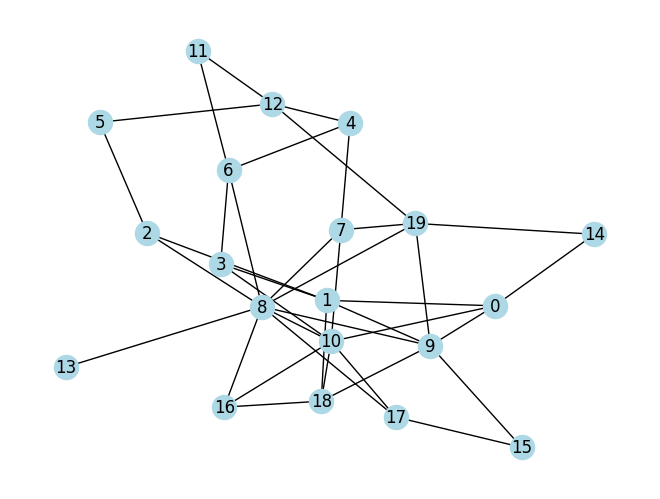

W shape: (20, 20)
Unique values in W: [0. 1.]


In [8]:
# GRAPH UTILITIES
def random_binary_undirected_graph(n_nodes=20, edge_prob=0.2, seed=1): # generate random undirected graph
    G = nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=False)
    return G
def draw_graph(G, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=True, node_color="lightblue")
    plt.show()
def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)
    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0
    return W

def draw_cut(G, x, seed=42):
    pos = nx.spring_layout(G, seed=seed)

    # node colors: 0 -> one color, 1 -> another
    node_colors = ["tab:blue" if x[i] == 0 else "tab:orange" for i in G.nodes()]

    # edge colors: cut edges in red, others in light gray
    edge_colors = []
    for u, v in G.edges():
        edge_colors.append("tab:red" if x[u] != x[v] else "lightgray")

    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors, width=2)
    plt.show()

# generate graph
G = random_binary_undirected_graph(n_nodes=20, edge_prob=0.2, seed=1)
draw_graph(G)
# adjacency matrix
W = graph_to_binary_adjacency(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

In [16]:
# --- device ---
device = "cpu"  # "mps" if torch.backends.mps.is_available() else "cpu"

# --- graph ---
W = torch.tensor(W, dtype=torch.float32).to(device)

# --- hyperparameters ---
batch = 64
q = 2
n = W.shape[0]
beta_range = torch.linspace(0.5, 20.0, steps=200).to(device)

# --- learnable fields ---
h = torch.nn.Parameter(torch.rand(batch, n, q, device=device))
device

/var/folders/hs/wzcwdwgd39lbf4_c_gqzw19r0000gn/T/ipykernel_31369/308716878.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  W = torch.tensor(W, dtype=torch.float32).to(device)


'cpu'

In [17]:
print("Number of edges:", len(G.edges()))
print("W sum:", W.sum())

Number of edges: 38
W sum: tensor(76.)


In [ ]:
def cut(W, p):
    # W: (n,n), p: (batch,n,q)
    return ((W @ p) * (1 - p)).sum((1, 2))

def S(p, eps=1e-12):
    p = p.clamp_min(eps)
    return -(p * p.log()).sum(2).sum(1)

def argmax_cut(W, p):
    config = p.argmax(dim=2)  # (batch,n)
    s = F.one_hot(config, num_classes=p.shape[2]).float()
    return config, cut(W, s) / 2

def solve_maxcut(W, batch=64, lr=0.01, steps=200):
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    W = torch.tensor(W, dtype=torch.float32).to(device)
    n = W.shape[0]
    q = 2
    torch.manual_seed(123)  # match pipeline seed
    h = torch.nn.Parameter(torch.rand(batch, n, q, device=device))
    optimizer = torch.optim.Adam([h], lr=lr)
    beta_range = torch.linspace(0.5, 20.0, steps=steps).to(device)

    for beta in beta_range:
        p = torch.softmax(h, dim=2)
        Fval = -cut(W, p) - S(p) / beta

        optimizer.zero_grad()
        Fval.backward(torch.ones_like(Fval))
        optimizer.step()

    p_final = torch.softmax(h, dim=2)
    config, cutvals = argmax_cut(W, p_final)
    return config, cutvals, p_final, h.detach()

In [15]:
# solve
config, cutvals, p, h_final = solve_maxcut(W, batch=64, steps=500)

# pick best replica r*
best = cutvals.argmax().item()
p_best = p[best]
h_best = h_final[best]

W_cpu = W.detach().cpu() if W.device.type != "cpu" else W
p_best_cpu = p_best.detach().cpu()
h_best_cpu = h_best.detach().cpu()


# local scores: (n,)
score0 = (W_cpu @ p_best_cpu[:, 1])  # sum_j W_ij * p_j(1)
score1 = (W_cpu @ p_best_cpu[:, 0])  # sum_j W_ij * p_j(0)
local_argmax = (score1 > score0).int()  # 1 if score1 bigger else 0

best_cut = cutvals[best].item()
best_config = local_argmax

print("Best cut value:", best_cut)
print("h_best:\n", h_best_cpu)
print("p_best:\n", p_best_cpu)
#print("score0:", score0)
#print("score1:", score1)
print("local_argmax partition:", local_argmax.numpy())


/var/folders/hs/wzcwdwgd39lbf4_c_gqzw19r0000gn/T/ipykernel_31369/975283285.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  W = torch.tensor(W, dtype=torch.float32).to(device)


Best cut value: 32.0
h_best:
 tensor([[-2.0503,  3.7621],
        [ 3.1224, -1.6846],
        [ 3.4312, -2.0036],
        [-1.9316,  3.2221],
        [-2.2482,  3.2228],
        [-1.7358,  3.5151],
        [ 3.2203, -2.1856],
        [ 2.9255, -2.0036],
        [-2.1780,  3.3502],
        [ 3.0768, -2.6111],
        [ 2.8373, -1.1850],
        [-2.3234,  2.9840],
        [ 3.4801, -2.4362],
        [ 2.7005, -2.4245],
        [ 2.9249, -2.6308],
        [-1.8856,  3.1882],
        [ 2.4754, -2.4163],
        [ 2.7374, -1.7417],
        [-2.0456,  3.4104],
        [-1.9403,  2.5595]])
p_best:
 tensor([[0.0030, 0.9970],
        [0.9919, 0.0081],
        [0.9957, 0.0043],
        [0.0057, 0.9943],
        [0.0042, 0.9958],
        [0.0052, 0.9948],
        [0.9955, 0.0045],
        [0.9928, 0.0072],
        [0.0040, 0.9960],
        [0.9966, 0.0034],
        [0.9824, 0.0176],
        [0.0049, 0.9951],
        [0.9973, 0.0027],
        [0.9941, 0.0059],
        [0.9961, 0.0039],
        [0

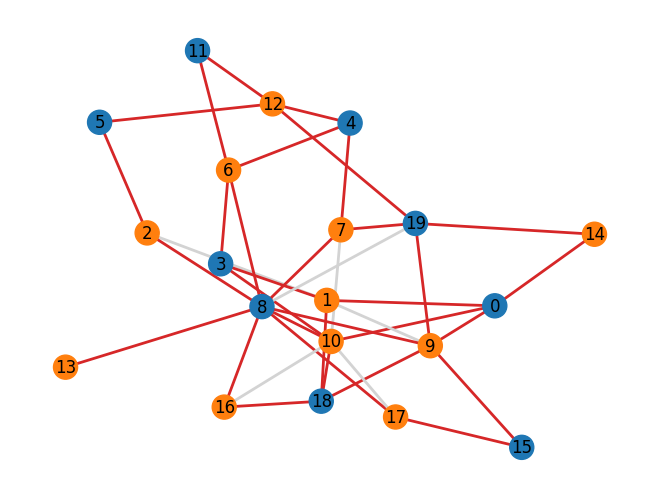

,logit_0,logit_1,marginal_p(0),marginal_p(1)
0,3.231817,-2.138467,0.995369,0.004631
1,-2.291393,2.803716,0.006089,0.993911
2,-2.175691,3.017083,0.005526,0.994474
3,2.922839,-2.290511,0.994586,0.005414
4,2.760159,-2.301048,0.993702,0.006298
5,2.934687,-2.426880,0.995328,0.004672
6,-2.253633,3.102721,0.004696,0.995304
7,-1.890324,3.092074,0.006811,0.993189
8,3.383771,-1.847588,0.994682,0.005318
9,-1.908331,3.333803,0.005261,0.994739


In [13]:
x = best_config.cpu().numpy()
import pandas as pd
def maxcut_marginals_dataframe(h_best, p_best):
    n = h_best.shape[0]
    df = pd.DataFrame({
        "logit_0": h_best_cpu[:, 0],
        "logit_1": h_best_cpu[:, 1],
        "marginal_p(0)": p_best_cpu[:, 0],
        "marginal_p(1)": p_best_cpu[:, 1],
    })
    return df

# ---- usage ----
df_maxcut = maxcut_marginals_dataframe(h_best, p_best)
draw_cut(G,x)
df_maxcut

# Verify

In [7]:
# enumerate all configurations to test if best_config is acutally the best
# Note: Running on CPU to avoid MPS allocation issues with large bitwise operations
import torch

# Move W to CPU for enumeration
W_cpu = W.detach().cpu()
num_nodes = W_cpu.shape[0]

# 1. Generate all 2^N binary configurations on CPU
#    N=20 -> 2^20 = ~1 million rows. Fits easily in CPU memory.
indices = torch.arange(2**num_nodes, device='cpu', dtype=torch.long)
steps = torch.arange(num_nodes, device='cpu')
configs = ((indices.unsqueeze(1) >> steps) & 1).float()

# 2. Calculate Cut Value for each configuration
#    Cut = 0.5 * x^T W (1-x)
cut_values = ((configs @ W_cpu) * (1 - configs)).sum(dim=1)

# 3. Find global maximum
max_cut_val, max_idx = cut_values.max(dim=0)
best_config_exact = configs[max_idx]

print(f"Exact MaxCut Value (Brute force on CPU): {max_cut_val.item()}")
print(f"FEM Best Cut Value: {best_cut}")

# Verify if FEM result is optimal
# Use a small epsilon for float comparison safety
if max_cut_val.item() > best_cut + 1e-4:
    print("FEM did NOT find the global optimum.")
else:
    print("FEM found the global optimum!")
print(best_config_exact)

Exact MaxCut Value (Brute force on CPU): 21.0
FEM Best Cut Value: 21.0
FEM found the global optimum!
tensor([0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0.,
        0., 0.])


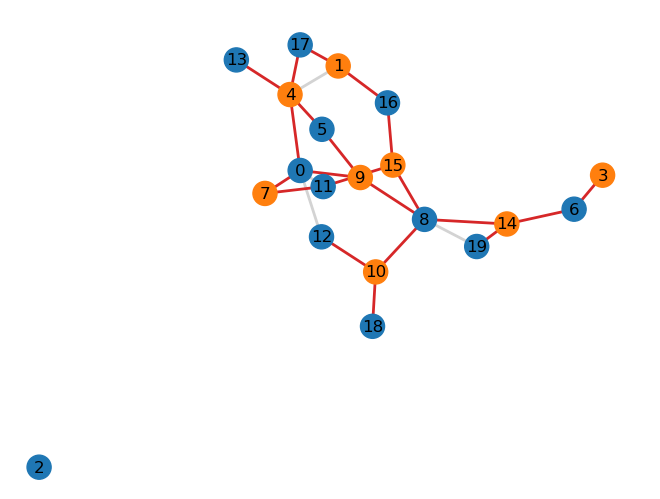

In [8]:
x = best_config_exact.cpu().numpy()
draw_cut(G, x)